In [1]:
import pandas as pd
import seaborn as sns
import sklearn
print("พร้อมแล้ว!", pd.__version__, sklearn.__version__)

พร้อมแล้ว! 3.0.6 1.9.1


In [2]:
df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.shape

(891, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [6]:
df.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [11]:
df["Survived"].mean()

np.float64(0.3838383838383838)

In [14]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [16]:
df.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

<Axes: xlabel='Sex', ylabel='Survived'>

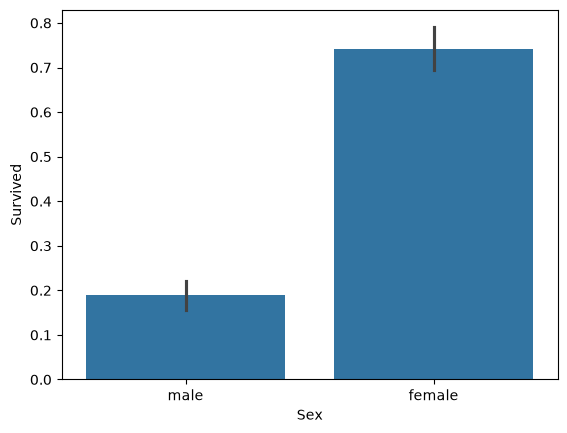

In [17]:
sns.barplot(data=df, x="Sex", y="Survived")

In [19]:
df.groupby("Pclass")["Survived"].mean()


Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

<Axes: xlabel='Pclass', ylabel='Survived'>

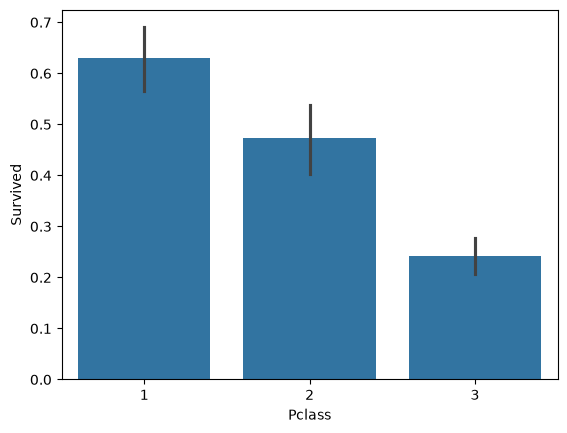

In [24]:
sns.barplot(data=df, x="Pclass", y="Survived")

In [25]:
df["Pclass"].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [28]:
pd.crosstab(df["Sex"], df["Survived"])

Survived,0,1
Sex,,
female,81,233
male,468,109


In [30]:
pd.crosstab(df["Sex"], df["Survived"], normalize="index")

Survived,0,1
Sex,,
female,0.257962,0.742038
male,0.811092,0.188908


<Axes: xlabel='Pclass', ylabel='Survived'>

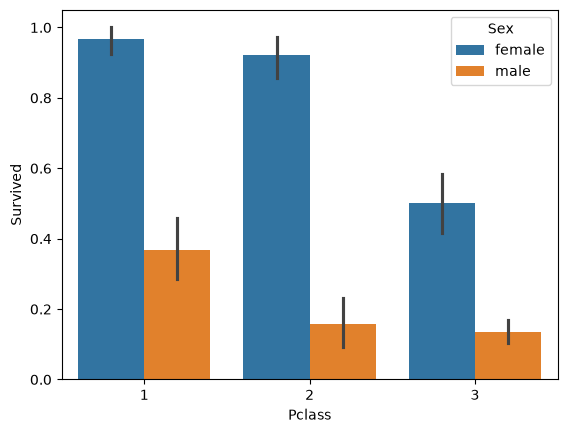

In [31]:
sns.barplot(data=df, x="Pclass", y="Survived", hue="Sex")

<Axes: xlabel='Age', ylabel='Count'>

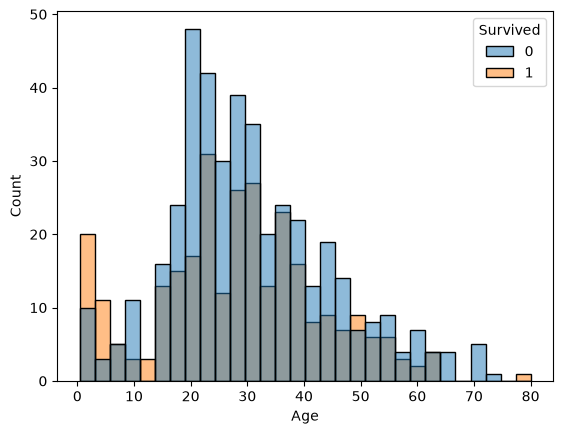

In [35]:
sns.histplot(data=df, x="Age", hue="Survived", bins=30)

In [36]:
kids=df[df["Age"] < 13 ]
kids.value_counts()

PassengerId  Survived  Pclass  Name                                 Sex     Age    SibSp  Parch  Ticket   Fare      Cabin    Embarked
11           1         3       Sandstrom, Miss. Marguerite Rut      female  4.00   1      1      PP 9549  16.7000   G6       S           1
184          1         2       Becker, Master. Richard F            male    1.00   2      1      230136   39.0000   F4       S           1
194          1         2       Navratil, Master. Michel M           male    3.00   1      1      230080   26.0000   F2       S           1
206          0         3       Strom, Miss. Telma Matilda           female  2.00   0      1      347054   10.4625   G6       S           1
298          0         1       Allison, Miss. Helen Loraine         female  2.00   1      2      113781   151.5500  C22 C26  S           1
306          1         1       Allison, Master. Hudson Trevor       male    0.92   1      2      113781   151.5500  C22 C26  S           1
341          1         2       N

In [37]:
kids["Survived"].mean()

np.float64(0.5797101449275363)

In [39]:
adult=df[df["Age"] >= 13]
adult["Survived"].mean()

np.float64(0.3875968992248062)

In [52]:
df["AgeGroup"] = pd.cut(df["Age"], bins=[0, 12, 100], labels=["kids", "adult"])
df[["Age", "AgeGroup"]].head(10)

,Age,AgeGroup
0,22.0,adult
1,38.0,adult
2,26.0,adult
3,35.0,adult
4,35.0,adult
5,NaN,NaN
6,54.0,adult
7,2.0,kids
8,27.0,adult
9,14.0,adult


<Axes: xlabel='AgeGroup', ylabel='Survived'>

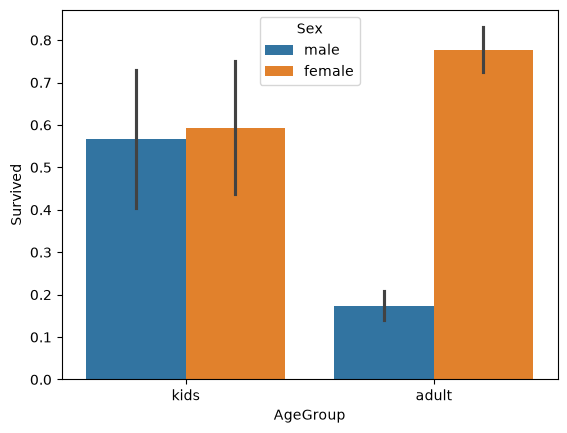

In [55]:
sns.barplot(data=df, x="AgeGroup", y="Survived", hue="Sex")